# Building Features for Forecasting the Demand for a chemical in a manufacturing plant (Ltrs).
#
# This data after feature engineering can be used to forecast Monthly/Bi-Monthly/Quarterly demand

# 1. Generate Synthetic Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate Synthetic Data. Data for THREE Years.
date_rng = pd.date_range(start='2020-01-01', end='2023-12-01', freq='MS')
np.random.seed(42)

# Creates a linear upward trend from 100 to 200 over the time period
trend = np.linspace(100, 200, len(date_rng))
# Generates repeating yearly seasonal fluctuations using a sine wave
seasonality = 20 * np.sin(2 * np.pi * date_rng.month / 12)
# Adds random variation (noise) with mean 0 and standard deviation 5
noise = np.random.normal(0, 5, len(date_rng))

demand_qty = trend + seasonality + noise
df = pd.DataFrame({'Month': date_rng, 'DemandQty': demand_qty})
df

# DemandQty is already at a monthly aggregated level (one value per month).

,Month,DemandQty
0,2020-01-01,112.483571
1,2020-02-01,118.756846
2,2020-03-01,127.493762
3,2020-04-01,131.318636
4,2020-05-01,117.339871
5,2020-06-01,109.467613
6,2020-07-01,110.662022
7,2020-08-01,101.410283
8,2020-09-01,94.673905
9,2020-10-01,104.541228


### NOTE: In the above df, the DemandQty is already at a monthly aggregated level (one value per month).

In [2]:
df['Month'].max()

Timestamp('2023-12-01 00:00:00')

In [3]:
df['Month'].min()

Timestamp('2020-01-01 00:00:00')

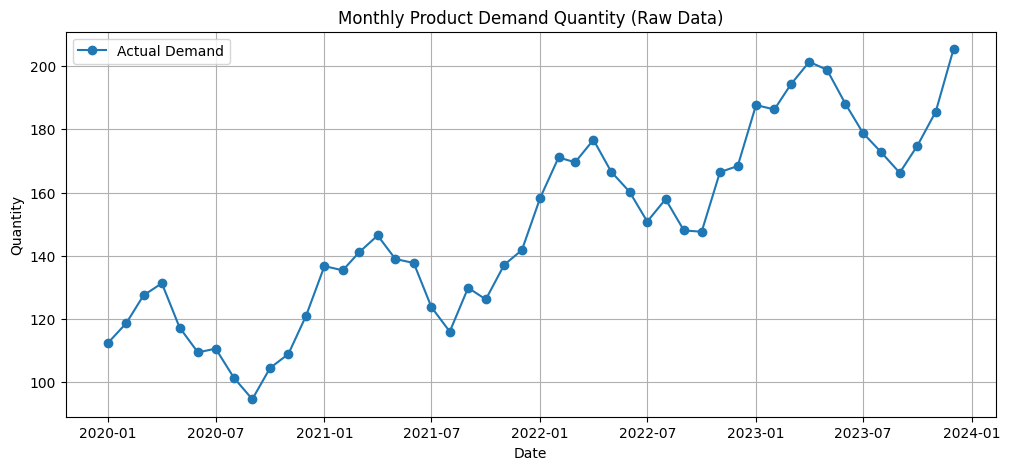

In [4]:
# Plot the raw data
plt.figure(figsize=(12, 5))
plt.plot(df['Month'], df['DemandQty'], marker='o', label='Actual Demand')
plt.title('Monthly Product Demand Quantity (Raw Data)')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.grid(True)
plt.legend()
plt.show()

# 2. Extract Temporal Features

In [5]:
# 2. Extract Temporal Features
df['Year'] = df['Month'].dt.year
df['Month_Num'] = df['Month'].dt.month
df['Quarter'] = df['Month'].dt.quarter
df['IsYearStart'] = df['Month'].dt.is_year_start.astype(int) # built-in attribute
df['IsYearEnd'] = df['Month'].dt.is_year_end.astype(int)     # built-in attribute

# Categorical Season (Example)
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Fall'

df['Season'] = df['Month_Num'].apply(get_season)

df.head()

,Month,DemandQty,Year,Month_Num,Quarter,IsYearStart,IsYearEnd,Season
0,2020-01-01,112.483571,2020,1,1,1,0,Winter
1,2020-02-01,118.756846,2020,2,1,0,0,Winter
2,2020-03-01,127.493762,2020,3,1,0,0,Spring
3,2020-04-01,131.318636,2020,4,2,0,0,Spring
4,2020-05-01,117.339871,2020,5,2,0,0,Spring


# 3: Lag-Based Features (The "Memory" of the Model)

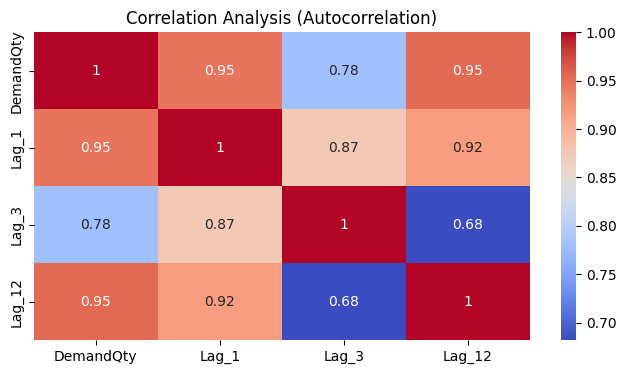

In [6]:
# 3. Create Quantity Lags
# We use shift(1) for Lag-1, shift(2) for Lag-2, etc.
df['Lag_1'] = df['DemandQty'].shift(1)
df['Lag_3'] = df['DemandQty'].shift(3)
df['Lag_12'] = df['DemandQty'].shift(12) # Yearly lag for seasonality

# Correlation Plot (ACF-like visualization)
plt.figure(figsize=(8, 4))
sns.heatmap(df[['DemandQty', 'Lag_1', 'Lag_3', 'Lag_12']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Analysis (Autocorrelation)')
plt.show()

- Seems the DemandQty is highly correlated with Lag_1 and Lag_12. Lag_12 is also strong because of yearly seasonality.


# 4: Rolling Mean and Trend Lags

In [7]:
# 4. Rolling Statistics and Trend Lags
# 3-Month Rolling Mean
df['RollingMean_3M'] = df['DemandQty'].rolling(window=3).mean()

# To avoid leakage, we must LAG the rolling mean
df['Trend_Lag_1'] = df['RollingMean_3M'].shift(1)
df['Trend_Lag_2'] = df['RollingMean_3M'].shift(2)
df


,Month,DemandQty,Year,Month_Num,Quarter,IsYearStart,IsYearEnd,Season,Lag_1,Lag_3,Lag_12,RollingMean_3M,Trend_Lag_1,Trend_Lag_2
0,2020-01-01,112.483571,2020,1,1,1,0,Winter,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-02-01,118.756846,2020,2,1,0,0,Winter,112.483571,NaN,NaN,NaN,NaN,NaN
2,2020-03-01,127.493762,2020,3,1,0,0,Spring,118.756846,NaN,NaN,119.578060,NaN,NaN
3,2020-04-01,131.318636,2020,4,2,0,0,Spring,127.493762,112.483571,NaN,125.856415,119.578060,NaN
4,2020-05-01,117.339871,2020,5,2,0,0,Spring,131.318636,118.756846,NaN,125.384090,125.856415,119.578060
5,2020-06-01,109.467613,2020,6,2,0,0,Summer,117.339871,127.493762,NaN,119.375374,125.384090,125.856415
6,2020-07-01,110.662022,2020,7,3,0,0,Summer,109.467613,131.318636,NaN,112.489835,119.375374,125.384090
7,2020-08-01,101.410283,2020,8,3,0,0,Summer,110.662022,117.339871,NaN,107.179972,112.489835,119.375374
8,2020-09-01,94.673905,2020,9,3,0,0,Fall,101.410283,109.467613,NaN,102.248736,107.179972,112.489835
9,2020-10-01,104.541228,2020,10,4,0,0,Fall,94.673905,110.662022,NaN,100.208472,102.248736,107.179972


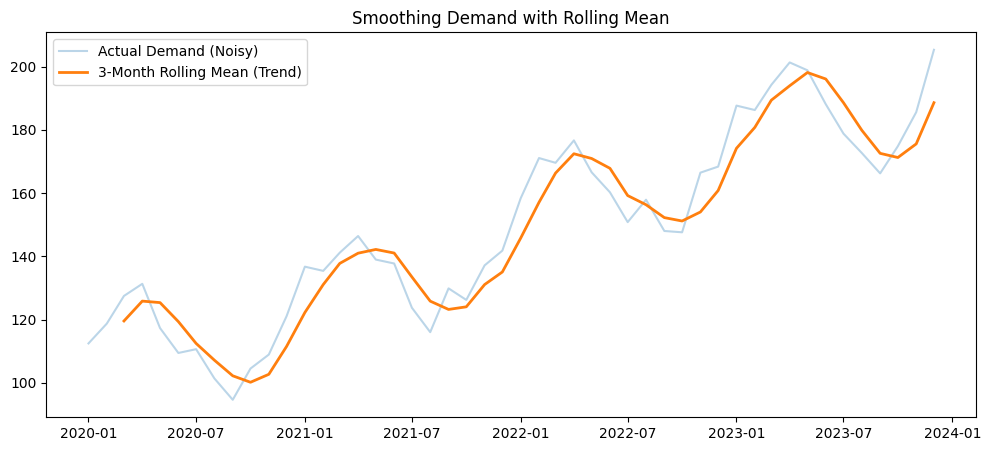

In [8]:
# Visualization
plt.figure(figsize=(12, 5))
plt.plot(df['Month'], df['DemandQty'], alpha=0.3, label='Actual Demand (Noisy)')
plt.plot(df['Month'], df['RollingMean_3M'], label='3-Month Rolling Mean (Trend)', linewidth=2)
plt.title('Smoothing Demand with Rolling Mean')
plt.legend()
plt.show()

Analysis:

Outcome: The orange line is much smoother than the blue one.


Why it happened: By averaging the last 3 months, we reduce short-term random fluctuations (Noise). Comparing Trend_Lag_1 and Trend_Lag_2 tells the model if the trend is accelerating or slowing down.

# 5: Variability and Sudden Shocks (Std Dev & EWMA)

In [9]:
# 5. Volatility and Shocks
# Rolling Std Dev (3-month window)
df['RollingStd_3M'] = df['DemandQty'].shift(1).rolling(window=3).std()

# Exponentially Weighted Moving Average (EWMA) with Alpha = 0.5
# High Alpha = reacts faster to recent spikes
df['EWMA_0.8'] = df['DemandQty'].shift(1).ewm(alpha=0.8, adjust=False).mean()
df


,Month,DemandQty,Year,Month_Num,Quarter,IsYearStart,IsYearEnd,Season,Lag_1,Lag_3,Lag_12,RollingMean_3M,Trend_Lag_1,Trend_Lag_2,RollingStd_3M,EWMA_0.8
0,2020-01-01,112.483571,2020,1,1,1,0,Winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-02-01,118.756846,2020,2,1,0,0,Winter,112.483571,NaN,NaN,NaN,NaN,NaN,NaN,112.483571
2,2020-03-01,127.493762,2020,3,1,0,0,Spring,118.756846,NaN,NaN,119.578060,NaN,NaN,NaN,117.502191
3,2020-04-01,131.318636,2020,4,2,0,0,Spring,127.493762,112.483571,NaN,125.856415,119.578060,NaN,7.538717,125.495448
4,2020-05-01,117.339871,2020,5,2,0,0,Spring,131.318636,118.756846,NaN,125.384090,125.856415,119.578060,6.438969,130.153998
5,2020-06-01,109.467613,2020,6,2,0,0,Summer,117.339871,127.493762,NaN,119.375374,125.384090,125.856415,7.224230,119.902697
6,2020-07-01,110.662022,2020,7,3,0,0,Summer,109.467613,131.318636,NaN,112.489835,119.375374,125.384090,11.066809,111.554630
7,2020-08-01,101.410283,2020,8,3,0,0,Summer,110.662022,117.339871,NaN,107.179972,112.489835,119.375374,4.242498,110.840543
8,2020-09-01,94.673905,2020,9,3,0,0,Fall,101.410283,109.467613,NaN,102.248736,107.179972,112.489835,5.032260,103.296335
9,2020-10-01,104.541228,2020,10,4,0,0,Fall,94.673905,110.662022,NaN,100.208472,102.248736,107.179972,8.026969,96.398391


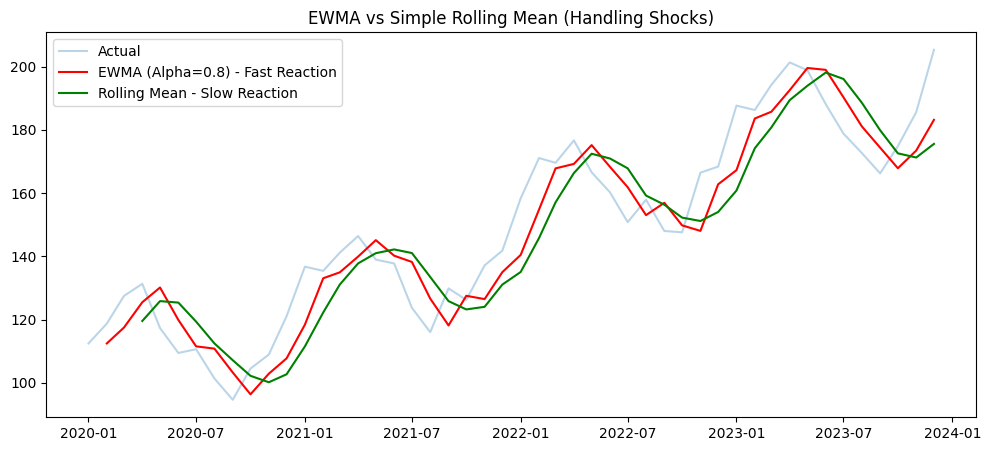

In [10]:
# Plotting EWMA vs Rolling Mean
plt.figure(figsize=(12, 5))
plt.plot(df['Month'], df['DemandQty'], alpha=0.3, label='Actual')
plt.plot(df['Month'], df['EWMA_0.8'], label='EWMA (Alpha=0.8) - Fast Reaction', color='red')
plt.plot(df['Month'], df['RollingMean_3M'].shift(1), label='Rolling Mean - Slow Reaction', color='green')
plt.title('EWMA vs Simple Rolling Mean (Handling Shocks)')
plt.legend()
plt.show()

Analysis:


Outcome: The EWMA line (red) tracks sudden changes more closely than the simple rolling mean (green).


Why it happened: EWMA gives higher weight to recent data points, making it superior for inventory planning during demand spikes or "shocks".

# 6: Difference Lags and Bollinger Bands

In [11]:
# 6. Difference Lags and Bollinger Bands
# Difference Lag-1 (Change from last month)
df['Diff_Lag_1'] = df['Lag_1'] - df['Lag_3']

# Bollinger Bands (k=2)
df['BB_Mid'] = df['RollingMean_3M'].shift(1)
df['BB_Upper'] = df['BB_Mid'] + (2 * df['RollingStd_3M'])
df['BB_Lower'] = df['BB_Mid'] - (2 * df['RollingStd_3M'])

# Indicator: Is Demand unusually high?
df['Above_Upper_Band'] = (df['DemandQty'] > df['BB_Upper']).astype(int)

df[['Month', 'DemandQty', 'BB_Upper', 'Above_Upper_Band']].tail(10)

,Month,DemandQty,BB_Upper,Above_Upper_Band
38,2023-03-01,194.210134,202.248224,0
39,2023-04-01,201.283538,197.871912,1
40,2023-05-01,198.798716,208.959853,0
41,2023-06-01,188.090884,205.274392,0
42,2023-07-01,178.783461,210.078604,0
43,2023-08-01,172.663335,208.589266,0
44,2023-09-01,166.224411,195.382803,0
45,2023-10-01,174.824952,185.117467,0
46,2023-11-01,185.569147,180.185624,1
47,2023-12-01,205.285611,194.923789,1


Analysis:

Outcome: We created an Above_Upper_Band indicator.


Why it happened: If the actual demand exceeds the Upper Band, it signals unusually high volatility or a potential reversal in the trend

# 7: Probabilistic Features (Intermittent Demand)

In [12]:
# 7. Purchase Probability
# Probability of purchase occurring (using a 6-month window)
# Converts demand into a binary indicator: 1 if a purchase occurred in that month, otherwise 0.
df['PurchaseOccurred'] = (df['DemandQty'] > 0).astype(int)

# Calculates the probability of purchase based on the PAST 6 months (excluding current month to avoid DATA LEAKAGE) as the average of
# binary purchase indicators.
df['PurchaseProb_6M'] = df['PurchaseOccurred'].shift(1).rolling(window=6).mean()

# Analysis of final feature set
print(df.columns)
df.head(10)

Index(['Month', 'DemandQty', 'Year', 'Month_Num', 'Quarter', 'IsYearStart',
       'IsYearEnd', 'Season', 'Lag_1', 'Lag_3', 'Lag_12', 'RollingMean_3M',
       'Trend_Lag_1', 'Trend_Lag_2', 'RollingStd_3M', 'EWMA_0.8', 'Diff_Lag_1',
       'BB_Mid', 'BB_Upper', 'BB_Lower', 'Above_Upper_Band',
       'PurchaseOccurred', 'PurchaseProb_6M'],
      dtype='object')


,Month,DemandQty,Year,Month_Num,Quarter,IsYearStart,IsYearEnd,Season,Lag_1,Lag_3,...,Trend_Lag_2,RollingStd_3M,EWMA_0.8,Diff_Lag_1,BB_Mid,BB_Upper,BB_Lower,Above_Upper_Band,PurchaseOccurred,PurchaseProb_6M
0,2020-01-01,112.483571,2020,1,1,1,0,Winter,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,NaN
1,2020-02-01,118.756846,2020,2,1,0,0,Winter,112.483571,NaN,...,NaN,NaN,112.483571,NaN,NaN,NaN,NaN,0,1,NaN
2,2020-03-01,127.493762,2020,3,1,0,0,Spring,118.756846,NaN,...,NaN,NaN,117.502191,NaN,NaN,NaN,NaN,0,1,NaN
3,2020-04-01,131.318636,2020,4,2,0,0,Spring,127.493762,112.483571,...,NaN,7.538717,125.495448,15.010191,119.578060,134.655493,104.500626,0,1,NaN
4,2020-05-01,117.339871,2020,5,2,0,0,Spring,131.318636,118.756846,...,119.578060,6.438969,130.153998,12.561790,125.856415,138.734353,112.978477,0,1,NaN
5,2020-06-01,109.467613,2020,6,2,0,0,Summer,117.339871,127.493762,...,125.856415,7.224230,119.902697,-10.153890,125.384090,139.832550,110.935629,0,1,NaN
6,2020-07-01,110.662022,2020,7,3,0,0,Summer,109.467613,131.318636,...,125.384090,11.066809,111.554630,-21.851023,119.375374,141.508991,97.241756,0,1,1.0
7,2020-08-01,101.410283,2020,8,3,0,0,Summer,110.662022,117.339871,...,119.375374,4.242498,110.840543,-6.677850,112.489835,120.974832,104.004839,0,1,1.0
8,2020-09-01,94.673905,2020,9,3,0,0,Fall,101.410283,109.467613,...,112.489835,5.032260,103.296335,-8.057330,107.179972,117.244493,97.115452,0,1,1.0
9,2020-10-01,104.541228,2020,10,4,0,0,Fall,94.673905,110.662022,...,107.179972,8.026969,96.398391,-15.988117,102.248736,118.302673,86.194799,0,1,1.0


Outcome: A PurchaseProb_6M feature is added.

Why it happened: In intermittent demand scenarios, lag features alone fail to distinguish between "low demand" and "no demand." Probability features predict whether a sale will occur.

# 8. Rolling Percentiles (Robustness against outliers)

In [13]:
# 8. Rolling Percentiles (Robustness against outliers)
# Computes distribution-based features (25th, 50th, 75th percentiles) from the previous 6 months
# to capture typical and extreme demand levels robustly.
# We use a 6-month window to get a stable distribution
# We MUST shift(1) to prevent data leakage from the current month
df['P25_6M'] = df['DemandQty'].shift(1).rolling(window=6).quantile(0.25)
df['P50_6M'] = df['DemandQty'].shift(1).rolling(window=6).quantile(0.50) # Median
df['P75_6M'] = df['DemandQty'].shift(1).rolling(window=6).quantile(0.75)
df


,Month,DemandQty,Year,Month_Num,Quarter,IsYearStart,IsYearEnd,Season,Lag_1,Lag_3,...,Diff_Lag_1,BB_Mid,BB_Upper,BB_Lower,Above_Upper_Band,PurchaseOccurred,PurchaseProb_6M,P25_6M,P50_6M,P75_6M
0,2020-01-01,112.483571,2020,1,1,1,0,Winter,NaN,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,NaN,NaN,NaN
1,2020-02-01,118.756846,2020,2,1,0,0,Winter,112.483571,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,NaN,NaN,NaN
2,2020-03-01,127.493762,2020,3,1,0,0,Spring,118.756846,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,NaN,NaN,NaN
3,2020-04-01,131.318636,2020,4,2,0,0,Spring,127.493762,112.483571,...,15.010191,119.578060,134.655493,104.500626,0,1,NaN,NaN,NaN,NaN
4,2020-05-01,117.339871,2020,5,2,0,0,Spring,131.318636,118.756846,...,12.561790,125.856415,138.734353,112.978477,0,1,NaN,NaN,NaN,NaN
5,2020-06-01,109.467613,2020,6,2,0,0,Summer,117.339871,127.493762,...,-10.153890,125.384090,139.832550,110.935629,0,1,NaN,NaN,NaN,NaN
6,2020-07-01,110.662022,2020,7,3,0,0,Summer,109.467613,131.318636,...,-21.851023,119.375374,141.508991,97.241756,0,1,1.0,113.697646,118.048359,125.309533
7,2020-08-01,101.410283,2020,8,3,0,0,Summer,110.662022,117.339871,...,-6.677850,112.489835,120.974832,104.004839,0,1,1.0,112.331484,118.048359,125.309533
8,2020-09-01,94.673905,2020,9,3,0,0,Fall,101.410283,109.467613,...,-8.057330,107.179972,117.244493,97.115452,0,1,1.0,109.766215,114.000946,124.955289
9,2020-10-01,104.541228,2020,10,4,0,0,Fall,94.673905,110.662022,...,-15.988117,102.248736,118.302673,86.194799,0,1,1.0,103.424615,110.064817,115.670409


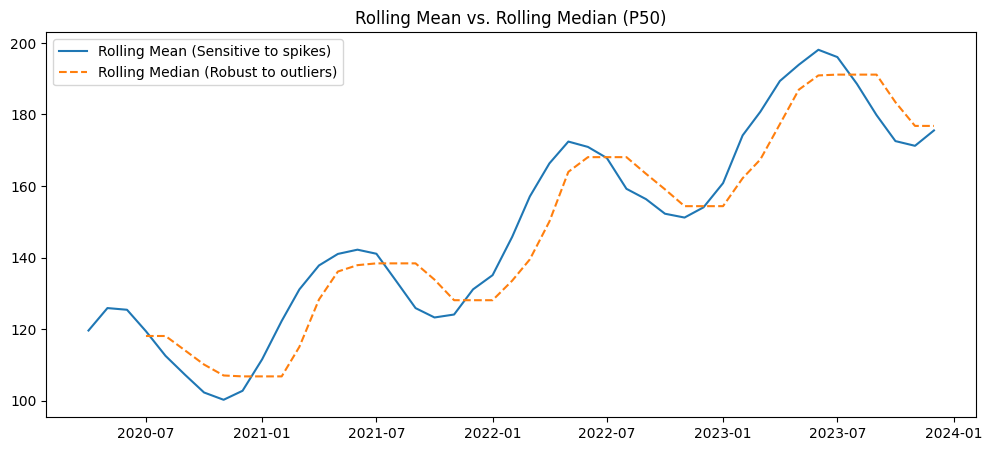

In [14]:
# Analysis: Comparison of Median vs Rolling Mean
plt.figure(figsize=(12, 5))
plt.plot(df['Month'], df['RollingMean_3M'].shift(1), label='Rolling Mean (Sensitive to spikes)')
plt.plot(df['Month'], df['P50_6M'], label='Rolling Median (Robust to outliers)', linestyle='--')
plt.title('Rolling Mean vs. Rolling Median (P50)')
plt.legend()
plt.show()

# 9: Frequency & Cumulative Features

In [15]:
# 9. Frequency and Consistency Features
# Binary indicator for a sale occurring
df['Has_Sale'] = (df['DemandQty'] > 0).astype(int)

# Cumulative Demand (Total sales since product launch)
df['Cumulative_Demand'] = df['DemandQty'].cumsum()

# Average Purchase Gap (How many months between sales on average)
# We calculate the distance between '1's in the Has_Sale column
df['Months_Since_Last_Sale'] = df['Has_Sale'].groupby((df['Has_Sale'] == 1).cumsum()).cumcount()

# Analysis:
df

,Month,DemandQty,Year,Month_Num,Quarter,IsYearStart,IsYearEnd,Season,Lag_1,Lag_3,...,BB_Lower,Above_Upper_Band,PurchaseOccurred,PurchaseProb_6M,P25_6M,P50_6M,P75_6M,Has_Sale,Cumulative_Demand,Months_Since_Last_Sale
0,2020-01-01,112.483571,2020,1,1,1,0,Winter,NaN,NaN,...,NaN,0,1,NaN,NaN,NaN,NaN,1,112.483571,0
1,2020-02-01,118.756846,2020,2,1,0,0,Winter,112.483571,NaN,...,NaN,0,1,NaN,NaN,NaN,NaN,1,231.240417,0
2,2020-03-01,127.493762,2020,3,1,0,0,Spring,118.756846,NaN,...,NaN,0,1,NaN,NaN,NaN,NaN,1,358.734179,0
3,2020-04-01,131.318636,2020,4,2,0,0,Spring,127.493762,112.483571,...,104.500626,0,1,NaN,NaN,NaN,NaN,1,490.052815,0
4,2020-05-01,117.339871,2020,5,2,0,0,Spring,131.318636,118.756846,...,112.978477,0,1,NaN,NaN,NaN,NaN,1,607.392686,0
5,2020-06-01,109.467613,2020,6,2,0,0,Summer,117.339871,127.493762,...,110.935629,0,1,NaN,NaN,NaN,NaN,1,716.860299,0
6,2020-07-01,110.662022,2020,7,3,0,0,Summer,109.467613,131.318636,...,97.241756,0,1,1.0,113.697646,118.048359,125.309533,1,827.522321,0
7,2020-08-01,101.410283,2020,8,3,0,0,Summer,110.662022,117.339871,...,104.004839,0,1,1.0,112.331484,118.048359,125.309533,1,928.932603,0
8,2020-09-01,94.673905,2020,9,3,0,0,Fall,101.410283,109.467613,...,97.115452,0,1,1.0,109.766215,114.000946,124.955289,1,1023.606508,0
9,2020-10-01,104.541228,2020,10,4,0,0,Fall,94.673905,110.662022,...,86.194799,0,1,1.0,103.424615,110.064817,115.670409,1,1128.147736,0


## Bollinger Bands (with shift to avoid leakage)

In [16]:
# Parameters
window = 3
k = 2

# Rolling statistics (use past data only)
df['Rolling_Mean'] = df['DemandQty'].shift(1).rolling(window=window).mean()
df['Rolling_Std'] = df['DemandQty'].shift(1).rolling(window=window).std()

# Bollinger Bands
df['Upper_Band'] = df['Rolling_Mean'] + (k * df['Rolling_Std'])
df['Lower_Band'] = df['Rolling_Mean'] - (k * df['Rolling_Std'])

# Indicator Features
df['Above_Upper_Band'] = (df['DemandQty'] > df['Upper_Band']).astype(int)
df['Below_Lower_Band'] = (df['DemandQty'] < df['Lower_Band']).astype(int)

# Distance Features (very useful)
df['Dist_From_Mean'] = df['DemandQty'] - df['Rolling_Mean']
df['Z_Score'] = df['Dist_From_Mean'] / df['Rolling_Std']

## RSI (Wilder’s Method using EWMA)

In [17]:
window = 3  # you can also use 14 (standard in finance)

# Step 1: Change
df['Change'] = df['DemandQty'].diff()

# Step 2: Gains and Losses
df['Gain'] = df['Change'].clip(lower=0)
df['Loss'] = -df['Change'].clip(upper=0)

# Step 3: Exponential Moving Average (Wilder's smoothing)
avg_gain = df['Gain'].ewm(alpha=1/window, adjust=False).mean()
avg_loss = df['Loss'].ewm(alpha=1/window, adjust=False).mean()

# Step 4: RS and RSI
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

In [18]:
df.head(50)

,Month,DemandQty,Year,Month_Num,Quarter,IsYearStart,IsYearEnd,Season,Lag_1,Lag_3,...,Rolling_Std,Upper_Band,Lower_Band,Below_Lower_Band,Dist_From_Mean,Z_Score,Change,Gain,Loss,RSI
0,2020-01-01,112.483571,2020,1,1,1,0,Winter,NaN,NaN,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-02-01,118.756846,2020,2,1,0,0,Winter,112.483571,NaN,...,NaN,NaN,NaN,0,NaN,NaN,6.273275,6.273275,-0.000000,100.000000
2,2020-03-01,127.493762,2020,3,1,0,0,Spring,118.756846,NaN,...,NaN,NaN,NaN,0,NaN,NaN,8.736916,8.736916,-0.000000,100.000000
3,2020-04-01,131.318636,2020,4,2,0,0,Spring,127.493762,112.483571,...,7.538717,134.655493,104.500626,0,11.740576,1.557371,3.824874,3.824874,-0.000000,100.000000
4,2020-05-01,117.339871,2020,5,2,0,0,Spring,131.318636,118.756846,...,6.438969,138.734353,112.978477,0,-8.516543,-1.322656,-13.978765,0.000000,13.978765,46.210693
5,2020-06-01,109.467613,2020,6,2,0,0,Summer,117.339871,127.493762,...,7.224230,139.832550,110.935629,1,-15.916477,-2.203207,-7.872258,0.000000,7.872258,31.773499
6,2020-07-01,110.662022,2020,7,3,0,0,Summer,109.467613,131.318636,...,11.066809,141.508991,97.241756,0,-8.713352,-0.787341,1.194408,1.194408,-0.000000,36.302549
7,2020-08-01,101.410283,2020,8,3,0,0,Summer,110.662022,117.339871,...,4.242498,120.974832,104.004839,1,-11.079553,-2.611563,-9.251739,0.000000,9.251739,20.495017
8,2020-09-01,94.673905,2020,9,3,0,0,Fall,101.410283,109.467613,...,5.032260,117.244493,97.115452,1,-12.506068,-2.485179,-6.736378,0.000000,6.736378,13.889488
9,2020-10-01,104.541228,2020,10,4,0,0,Fall,94.673905,110.662022,...,8.026969,118.302673,86.194799,0,2.292492,0.285599,9.867324,9.867324,-0.000000,49.588350
